In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes', 'gymnasium']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact'), 'gymnasium': ('1.2.3', 'gymnasium[toy-text]==1.2.3', 'gymnasium[toy-text]==1.2.3', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "0114bae219d4d94bc9d18a2e1ab76c089e2dc890"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/0114bae219d4d94bc9d18a2e1ab76c089e2dc890/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Actor-Critic Methods and Multi-Step Returns

that section estimated advantages from complete sampled returns, so an update could be formed only after an episode ended. An actor--critic method instead uses a learned value function to bootstrap from incomplete trajectories [@Barto.Sutton.Anderson.1983; @Konda.Tsitsiklis.2000]. The *actor* is the policy $\pi_\theta$, and the *critic* estimates its value $V^{\pi_\theta}$.

Bootstrapping reduces the amount of future randomness in each target but introduces error from the critic. This section derives the one-step temporal-difference target, extends it to $n$-step and $\lambda$-returns, and implements generalized advantage estimation (GAE). Experiments on CartPole compare these estimators through their gradient error, training stability, and sensitivity to critic fitting.

In [1]:
%matplotlib inline
from d2l import jax as d2l
from flax import nnx
import gymnasium as gym
import jax
from jax import numpy as jnp
import numpy as np
import optax

We retain the CartPole environment, discount $0.99$, and one-hidden-layer `ActorCritic.mlp` model from that section. The new hyperparameter `critic_steps` specifies the number of critic regression passes per batch. Unless stated otherwise, we use twenty passes and recompute the target before each pass.

In [2]:
gamma, num_updates, batch_episodes = 0.99, 100, 8
num_seeds, critic_steps, grad_clip = 3, 20, 0.5
def cartpole_agent(seed):
    return d2l.ActorCritic.mlp(4, 2, rngs=nnx.Rngs(seed))

## Bootstrapping the Reward-to-Go

### The TD Error

Write out one step of what the reward-to-go contains,

$$\hat{G}_t = r_t + \gamma\, \hat{G}_{t+1},$$

and recall what the learned baseline of that section is trained on: $\hat{V}(s_{t+1})$ regresses toward exactly the quantity that $\hat{G}_{t+1}$ samples. So stop waiting for the sample and substitute the prediction, $\hat{G}_t \approx r_t + \gamma \hat{V}(s_{t+1})$. The weight on the score at step $t$ was $\hat{G}_t - \hat{V}(s_t)$; after the substitution it becomes

$$\delta_t = r_t + \gamma\, \hat{V}(s_{t+1}) - \hat{V}(s_t),$$

with the convention $\hat{V}(s_{t+1}) = 0$ when $s_{t+1}$ is terminal. This is the temporal-difference error of the equation, adapted to policy evaluation. Q-learning bootstraps on the greedy continuation $\max_{a'} \hat{Q}(s', a')$ because it estimates $Q^*$; here the bootstrap uses the current policy's continuation value $\hat{V}(s_{t+1})$. As in Q-learning, the terminal mask is determined by `terminated`, not `truncated`, because a time limit stops the observation without making the continuation value zero (that section). The `bootstrap` function below returns a numpy array, so the target contains no autograd history and requires no explicit `detach`.

In [3]:
@d2l.add_to_class(d2l.Batch)
def td_target(self, bootstrap, gamma):
    """r_t + gamma (1 - terminated) V(s'), by a numpy bootstrap."""
    return self.rew + gamma * (1 - self.term) * bootstrap(self.next_obs)

As in the equation, we omit the factor $\gamma^t$ from the actor update. The consequences of this convention were discussed in that section.

### The TD Error as an Advantage Estimate

The TD error is not merely cheaper than the Monte Carlo weight; it estimates the same thing. Suppose for a moment the critic were exact, $\hat{V} = V^\pi$. Averaging the equation over the next state,

$$E\big[ \delta_t \mid s_t, a_t \big] = r(s_t, a_t) + \gamma \sum_{s'} P(s' \mid s_t, a_t)\, V^{\pi}(s') - V^{\pi}(s_t) = Q^{\pi}(s_t, a_t) - V^{\pi}(s_t),$$

where the second equality is the equation written with $V^\pi$. The right-hand side is the advantage the equation of the action taken, the exact quantity the learned baseline of that section estimated with $\hat{G}_t - \hat{V}(s_t)$. So a single transition, one reward plus two critic evaluations, yields an unbiased one-sample estimate of the advantage, where the Monte Carlo estimate needed the entire remaining trajectory.

During training $\hat{V}$ is generally not equal to $V^\pi$. Consequently, $\delta_t$ is a biased estimate of the advantage, and the resulting policy update is not an unbiased gradient estimator of $J(\theta)$. The baseline lemma of that section does not apply to the bootstrap term: unlike a state-dependent baseline at time $t$, $\hat{V}(s_{t+1})$ depends on the sampled action through the next state. Exercise 1 identifies the corresponding step in the proof. Bootstrapping therefore exchanges some variance for bias.

### The Critic as Sampled Policy Evaluation

The critic update is a sampled form of policy evaluation. In that section, policy evaluation applied a Bellman expectation operator whose fixed point is $V^\pi$. Regressing $\hat{V}(s_t)$ toward $r_t + \gamma \hat{V}(s_{t+1})$ replaces that expectation by one sampled transition, just as Q-learning replaced the Bellman optimality expectation by a sample in that section. Actor-critic can therefore be viewed as approximate generalized policy iteration: the critic estimates $V^{\pi_\theta}$, while the actor improves the policy using that estimate. Because the regression target itself contains $\hat{V}$, the critic update is a semi-gradient toward a fixed point rather than gradient descent on a fixed supervised-learning objective.

### The Bias-Variance Trade-off

The two advantage estimates have complementary errors. The Monte Carlo estimate is unbiased but includes randomness from every remaining transition, so its variance tends to grow with the horizon. The one-step TD error depends on only one transition, but it inherits bias from the critic. Targets that bootstrap after $n$ steps interpolate between these cases. In the synthetic chain in the figure, the critic becomes more accurate near termination; increasing $n$ therefore reduces bias and increases variance, with the smallest mean squared error at an intermediate depth. This pattern depends on the example and is not a general monotonicity result.

![The credit-assignment dial. Left: backup diagrams of depth one, two, $n$, and to termination; the green node is where the estimate stops sampling and starts trusting the critic, and the strip below shows the $\lambda$-return's weights $(1-\lambda)\lambda^{n-1}$ over the $n$-step targets at $\lambda = 0.9$. Right: the family measured on a synthetic ten-state chain, deterministic step right with only the final transition paying $1$, per-step reward noise of standard deviation $0.15$, and $\gamma = 0.97$, under a critic whose error tapers toward termination as $0.5\,(1 - s/9)^2$, the shape value learning actually produces; over $20{,}000$ rollouts of the depth-$n$ target from the start state, bias falls with depth, variance grows, and the mean squared error is smallest at $n = 4$. A critic equally wrong everywhere would make the error monotone in $n$; the interior optimum exists because deeper targets bootstrap from better-known states.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-td-mc-spectrum.svg)

## The Actor-Critic Algorithm

### The Actor and Critic Updates

Both learners now update from the same scalar. Writing $\hat{V}_w$ for the critic's parameters, the updates after the transition $(s_t, a_t, r_t, s_{t+1})$ are

$$w \leftarrow w + \alpha_w\, \delta_t\, \nabla_w \hat{V}_w(s_t), \qquad \theta \leftarrow \theta + \alpha_\theta\, \delta_t\, \nabla_\theta \log \pi_\theta(a_t \mid s_t).$$

The critic's update is the sampled policy evaluation of the previous section, a semi-gradient step toward the one-step target; the actor's is the policy gradient of that section with $\delta_t$ as the advantage weight. One number does both jobs: $\delta_t$ tells the critic how wrong its prediction was, and it tells the actor whether the action just taken was better or worse than the state's average. And because $\delta_t$ needs only a single transition, the equation can be applied at every step as the agent acts, the way Q-learning updates its table; nothing must terminate before learning starts, so the method extends to tasks that never end. REINFORCE, with or without a baseline, cannot say the same.

![The actor-critic loop. One transition produces one temporal-difference error, and that single number does both jobs: it tells the critic how wrong its prediction was, and it tells the actor whether the action it just took was better or worse than the state's average. Nothing waits for the episode to end.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-actor-critic-loop.svg)

### Two Timescales

The actor and critic have different optimization problems. Actor updates
change the policy and hence the value function being estimated; critic
updates also change the bootstrapped targets. If the actor changes much
faster than the critic, its advantages may be evaluated with stale value
estimates. Classical two-timescale results address this interaction using
separated, decaying step-size schedules under assumptions that this
experiment does not meet. Here both heads use the same nominal learning
rate, with `critic_steps` regression passes per batch. This is a heuristic,
not an implementation of the theorem's schedule.

### A Batched Actor-Critic and A2C

What we implement below is not the fully online the equation, and the difference deserves a careful name. The code collects a batch of eight episodes from one environment, gives the critic its `critic_steps` regression passes on the batch's one-step targets, and then takes a single actor step weighted by the TD errors of the freshly updated critic: call it a *batched on-policy actor-critic*. Its production relative is A2C, the advantage actor-critic, which conventionally denotes the synchronous multi-actor form: many environments stepped in lockstep with $n$-step rollouts, itself the synchronous descendant of an asynchronous original [@Mnih.Badia.Mirza.ea.2016]. Our single-environment, whole-episode loop keeps A2C's estimator and drops its vectorization. Exercise 5 takes up the fully online form, one update per transition with no batch at all, and what goes wrong there is a preview of that section.

We first modify `d2l.policy_step` to cap the actor's gradient norm at the commonly used value $0.5$. The function also reports the norm before clipping so that the experiments below can compare the scale of different advantage estimators.

In [4]:
def policy_step_clip(ac, batch, w, clip=grad_clip):
    """d2l.policy_step with the actor's gradient norm capped at `clip`;
    returns the norm measured before the cap. `_pad` and `_actor_pass`,
    defined with the critic's compilation story two cells below, are
    resolved at the first call."""
    size = 1 << max(6, (len(w) - 1).bit_length())
    gnorm = _actor_pass(ac.policy, ac.opt_pi, _pad(batch.obs, size),
                        _pad(batch.act, size), _pad(w, size),
                        jnp.float32(len(w)), jnp.float32(clip))
    return float(gnorm)

The second piece is per-framework speed, not algorithm, and follows the compilation rule of that section: compile what has a fixed shape and runs hot, leave ragged shapes eager. The acting forward runs a few hundred thousand times at one fixed shape, so the jax tab compiles and caches it exactly as that section did; the pytorch tab's eager dispatch is already cheap at this scale and needs nothing.

In [5]:
_act_probs = nnx.jit(lambda net, obs: jax.nn.softmax(net(obs), -1))

def _probs(ac, obs):   # the fixed-shape acting forward, compiled and
    if not hasattr(ac, '_fwd'):        # cached as in :numref:`sec_deeprl`
        ac._fwd = nnx.cached_partial(_act_probs, ac.policy)
    return np.asarray(ac._fwd(jnp.asarray(obs)))

@d2l.add_to_class(d2l.ActorCritic)
def act(self, obs, rng):
    p = _probs(self, obs)
    return int(rng.choice(len(p), p=p))

@d2l.add_to_class(d2l.ActorCritic)
def act_greedy(self, obs, rng=None):
    return int(_probs(self, obs).argmax())

The critic's regression and the actor's clipped step are this section's hot loops, together tens of thousands of passes per run, each on a batch of a few fixed lengths. Padding every batch to a power-of-two length makes the shape one of a handful and lets the jitted passes and the jitted value read that computes the critic's target compile once per bucket rather than once per batch; a mask, or zero-padded weights, keeps the padded entries out of each loss.

In [6]:
def _pad(x, size):
    return jnp.asarray(np.pad(x, ((0, size - len(x)),) + ((0, 0),)
                              * (x.ndim - 1)))

_value_fwd = nnx.jit(lambda net, obs: net(obs).squeeze(-1))

@d2l.add_to_class(d2l.ActorCritic)
def value_np(self, obs):   # batched reads only, padded to the bucket size
    size = 1 << max(6, (len(obs) - 1).bit_length())
    return np.asarray(_value_fwd(self.value, _pad(obs, size)))[:len(obs)]

@nnx.jit
def _critic_pass(value, opt, obs, target, mask):
    loss, grads = nnx.value_and_grad(lambda v: (mask * (
        v(obs).squeeze(-1) - target) ** 2).sum() / mask.sum())(value)
    opt.update(value, grads)
    return loss

@nnx.jit
def _actor_pass(policy, opt, obs, act, adv, n_real, clip):
    def loss_fn(p):   # zero-padded adv silences the padded rows exactly
        logp = jax.nn.log_softmax(p(obs), -1)[jnp.arange(obs.shape[0]), act]
        return -(adv * logp).sum() / n_real
    grads = nnx.grad(loss_fn)(policy)
    gnorm = optax.global_norm(grads)
    grads = jax.tree.map(lambda g: g * jnp.minimum(1.0, clip / gnorm), grads)
    opt.update(policy, grads)
    return gnorm

def fit_value(ac, obs, target, num_steps=1):
    """d2l.fit_value, padded to a power-of-two length: the jitted pass
    compiles once per size bucket (:numref:`sec_compilation`)."""
    size = 1 << max(6, (len(target) - 1).bit_length())
    mask = jnp.asarray((np.arange(size) < len(target)).astype(np.float32))
    for _ in range(num_steps):
        loss = _critic_pass(ac.value, ac.opt_v, _pad(obs, size),
                            _pad(target, size), mask)
    return float(loss)

Now the two training functions, side by side. The Monte Carlo reference is `train_reinforce` of that section with two mechanical changes: the agent arrives from the caller, following the pattern of that section's caller-owned tables, so that the last cell of this section can audit the trained agents; and the actor's step goes through the clipped variant and yields its gradient norm, a diagnostic returned as data.

In [7]:
def train_reinforce(seed, ac, num_updates=num_updates):
    """sec_deeprl's learned-baseline REINFORCE; the agent is caller-owned
    and the actor step reports its pre-clip gradient norm."""
    rng, env = np.random.default_rng(seed), gym.make('CartPole-v1')
    env.reset(seed=seed)
    for _ in range(num_updates):
        batch = d2l.rollout(env, ac.act, batch_episodes, rng)
        G = batch.reward_to_go(gamma)
        w = d2l.normalize(G - ac.value_np(batch.obs))
        gnorm = policy_step_clip(ac, batch, w)
        fit_value(ac, batch.obs, G)
        yield float(batch.episode_returns().mean()), gnorm

Actor--critic modifies the final part of the preceding training loop. The critic
regresses on the one-step bootstrapped target rather than reward-to-go and
takes `critic_steps` passes before the actor update. Each pass recomputes the
target from the current critic, so this is fitted TD with a moving target rather
than fixed-target regression. that section will instead freeze a separate
target network when learning off-policy. The actor uses the TD error from
the equation, normalized within the batch, as its weight.

In [8]:
def train_ac(seed, ac, num_updates=num_updates):
    """The same loop with the sampled tail replaced by the bootstrap."""
    rng, env = np.random.default_rng(seed), gym.make('CartPole-v1')
    env.reset(seed=seed)
    for _ in range(num_updates):
        batch = d2l.rollout(env, ac.act, batch_episodes, rng)
        for _ in range(critic_steps):   # fresh target, one pass, repeat
            fit_value(ac, batch.obs, batch.td_target(ac.value_np, gamma))
        delta = batch.td_target(ac.value_np, gamma) - ac.value_np(batch.obs)
        gnorm = policy_step_clip(ac, batch, d2l.normalize(delta))
        yield float(batch.episode_returns().mean()), gnorm

Three seeds each, with the agents kept. The reference arm first:

In [9]:
agents = {name: [cartpole_agent(s) for s in range(num_seeds)]
          for name in ('REINFORCE + baseline', 'actor-critic')}
runs = {'REINFORCE + baseline': np.array(
    [list(train_reinforce(s, agents['REINFORCE + baseline'][s]))
     for s in range(num_seeds)])}

Then the bootstrapped arm, and the comparison:

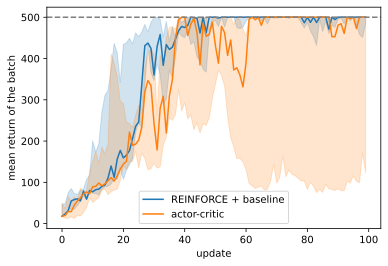

In [10]:
runs['actor-critic'] = np.array(
    [list(train_ac(s, agents['actor-critic'][s]))
     for s in range(num_seeds)])
d2l.plot_curves({name: r[:, :, 0] for name, r in runs.items()},
                xlabel='update', ylabel='mean return of the batch',
                reference=500)

The two curves are the trade of the figure drawn by the algorithms themselves. Actor-critic starts slower: for its first stretch the critic is still wrong, the TD errors point in poorly chosen directions, and the biased updates buy little, while the Monte Carlo weight is correct on average from the first batch. Then the curves stop differing in level, both reach the neighborhood of the ceiling, and start differing in *texture*. A batch mean of $500$ means every one of the batch's eight episodes ran the full 500 steps, a perfect batch; $500$ is CartPole's structural ceiling, so it can be tied but never beaten, and the informative comparison is not who is higher but who, having arrived, stays. The claim is checkable in four lines:

In [11]:
def longest_streak(hits):
    """The longest run of consecutive True entries."""
    best = run = 0
    for h in hits:
        run = run + 1 if h else 0
        best = max(best, run)
    return best

for name, r in runs.items():
    print(f'{name:>20}: longest stretch of perfect batches, per seed: '
          f'{[longest_streak(row == 500) for row in r[:, :, 0]]}')

REINFORCE + baseline: longest stretch of perfect batches, per seed: [26, 13, 22]
        actor-critic: longest stretch of perfect batches, per seed: [39, 22, 3]


Both methods reach the maximum batch return, but the bootstrapped runs remain there for longer consecutive intervals in every framework. The streak length is only a visualization of these runs: it depends on policy quality, batch size, environment randomness, and estimator variance, so it is not a standard stability metric.

The difference is consistent with the estimators' variance. A Monte Carlo weight contains the random outcomes of the entire remaining trajectory, so even a good policy can produce a lower-return update batch. A one-step temporal-difference weight replaces that tail with a critic estimate. The critic introduces bias early in training but reduces the variance that causes later fluctuations.

The training functions also brought back a second number, and it justifies the clip. Both methods scale their weights to unit variance before the update, so it is tempting to assume both take steps of the same size:

In [12]:
for name, r in runs.items():
    g = r[:, :, 1].ravel()
    print(f'{name:>20}: median pre-clip gradient norm {np.median(g):5.2f}, '
          f'clip binds on {(g > grad_clip).mean():4.0%} of updates')

REINFORCE + baseline: median pre-clip gradient norm  0.03, clip binds on   0% of updates
        actor-critic: median pre-clip gradient norm  0.33, clip binds on  30% of updates


In these runs, actor--critic gradients are roughly an order of magnitude larger. The norm clip activates on about one third of actor--critic updates and on none of the Monte Carlo updates. The baseline identity from that section helps explain this difference: state-dependent variance contributes nothing to the expected policy gradient, and the Monte Carlo weight contains more of it, whereas the temporal-difference error is more strongly action-dependent. Gradient norm alone does not measure signal quality, but the result shows that the two estimators can produce different update scales at the same learning rate. that section develops methods for controlling such policy updates.

### The Critic's Moving Target and Data Freshness

Every batch in this experiment comes from the current policy and from the states that policy visits. A critic error that affects current behavior is therefore likely to receive relevant transitions in the next batch, reducing the distributional mismatch between critic training and use. This feedback resembles the self-correction described in that section.

Fresh data do not guarantee stability. Nonlinear temporal-difference regression can diverge on-policy, and classical convergence results assume linear critics and two-timescale step sizes that this implementation does not use [@Tsitsiklis.VanRoy.1997]. In this experiment, the reduced mismatch is sufficient for stable training. To compare the two estimators directly, we rerun `train_ac` and measure the temporal-difference error and Monte Carlo advantage on each shared batch.

corr(TD error, MC advantage): mean 0.33 over the first ten updates, -0.03 over the last 50


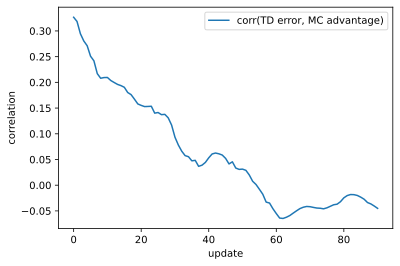

In [13]:
rng, env = np.random.default_rng(0), gym.make('CartPole-v1')
ac = cartpole_agent(0)
env.reset(seed=0)
trace = []
for _ in range(num_updates):
    b = d2l.rollout(env, ac.act, batch_episodes, rng)
    for _ in range(critic_steps):
        fit_value(ac, b.obs, b.td_target(ac.value_np, gamma))
    V = ac.value_np(b.obs)
    delta = b.td_target(ac.value_np, gamma) - V
    A_mc = b.reward_to_go(gamma) - V
    trace.append((np.corrcoef(delta, A_mc)[0, 1], delta.var(), A_mc.var()))
    policy_step_clip(ac, b, d2l.normalize(delta))
trace = np.array(trace)
print(f'corr(TD error, MC advantage): mean {trace[:10, 0].mean():.2f} over '
      f'the first ten updates, {trace[-50:, 0].mean():.2f} over the last 50')
d2l.plot_curves({'corr(TD error, MC advantage)': trace[:, 0]},
                xlabel='update', ylabel='correlation', smooth=10)

When episodes last a few dozen steps, the two weights have correlation near $0.3$; after episodes extend to hundreds of steps, the measured correlation approaches zero. Expanding the equation gives $\hat{G}_t-\hat{V}(s_t)=\delta_t+\gamma(\hat{G}_{t+1}-\hat{V}(s_{t+1}))$. The Monte Carlo advantage therefore contains the one-step temporal-difference error plus the discounted remainder of the trajectory. As the horizon grows, this additional tail contributes increasing variance.

The correlation is a descriptive diagnostic, not a certificate that the critic is accurate. It also changes with the policy, the state distribution, and the scales of both estimators. A direct critic evaluation would instead freeze the policy and compare predicted values with a reference. Here we next compare the absolute variances of the two policy weights:

median variance, MC advantage over TD error: 318x


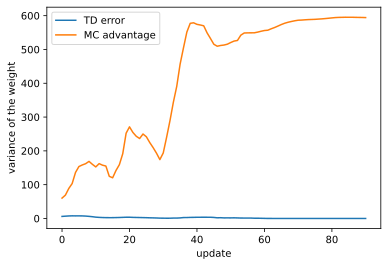

In [14]:
print(f'median variance, MC advantage over TD error: '
      f'{np.median(trace[:, 2] / trace[:, 1]):.0f}x')
d2l.plot_curves({'TD error': trace[:, 1], 'MC advantage': trace[:, 2]},
                xlabel='update', ylabel='variance of the weight', smooth=10)

As episodes approach 500 steps, the variance of the Monte Carlo weight grows from tens to several hundred squared units. The temporal-difference error depends on one reward and one transition, so its variance remains much smaller and decreases further as the critic improves. The median variance ratio exceeds one hundred. Averaging eight trajectories per update reduces the Monte Carlo variance enough for REINFORCE to train, but does not remove its dependence on the horizon.

Here the critic is trained on fresh on-policy data, and its target is recomputed after each update. When a value function is instead trained on replayed off-policy data while retaining a bootstrap target, the same semi-gradient update can diverge. that section addresses this problem by evaluating the bootstrap with a second network whose parameters are held fixed for several updates. This *target network* reduces the rate at which the regression target moves.

## n-Step Returns, Lambda-Returns and GAE

### n-Step Returns

The one-step target and the Monte Carlo return are endpoints of a family. Include $n$ sampled rewards and then bootstrap from the critic:

$$\hat{G}^{(n)}_t = r_t + \gamma\, r_{t+1} + \cdots + \gamma^{n-1} r_{t+n-1} + \gamma^n\, \hat{V}(s_{t+n}),$$

and use $\hat{G}^{(n)}_t-\hat{V}(s_t)$ as the advantage estimate. For $n=1$, this is $\delta_t$; when $n$ extends to the end of the episode, it becomes the Monte Carlo advantage. Increasing $n$ discounts the critic's error by $\gamma^n$ and evaluates it at a later state, but also adds another sampled reward and transition. The result is the bias--variance trade-off measured in the figure.

### The Lambda-Return and the Telescoping Identity

Rather than pick one depth, average them all, with geometric weights that make the average computable:

$$\hat{A}^{\textrm{GAE}}_t = (1 - \lambda) \sum_{n=1}^{\infty} \lambda^{n-1} \big( \hat{G}^{(n)}_t - \hat{V}(s_t) \big), \qquad \lambda \in [0, 1].$$

The weights $(1-\lambda)\lambda^{n-1}$ sum to one, $\lambda = 0$ puts everything on the one-step estimate, and $\lambda \to 1$ puts everything on the deepest one. Written this way the estimator looks like it needs every depth computed separately. It does not, and the identity that says so is why $\lambda$ survived into deployed implementations [@Schulman.Moritz.Levine.ea.2016].

**Proposition.** The mixture collapses to a discounted sum of TD errors:

$$
\hat{A}^{\textrm{GAE}}_t = \sum_{l=0}^{\infty} (\gamma\lambda)^l\, \delta_{t+l}.
$$

**Proof.** Each depth telescopes into TD errors: $\sum_{l=0}^{n-1} \gamma^l \delta_{t+l} = \sum_{l=0}^{n-1} \gamma^l r_{t+l} + \gamma^n \hat{V}(s_{t+n}) - \hat{V}(s_t) = \hat{G}^{(n)}_t - \hat{V}(s_t)$, the interior $\hat{V}$ terms cancelling in pairs. Substitute this into the equation and swap the two sums: the pair $(n, l)$ with $l < n$ contributes $(1-\lambda)\lambda^{n-1} \gamma^l \delta_{t+l}$, so $\hat{A}^{\textrm{GAE}}_t = \sum_{l \ge 0} \gamma^l \delta_{t+l}\, (1-\lambda) \sum_{n \ge l+1} \lambda^{n-1}$. The inner geometric sum is $\lambda^l$. $\blacksquare$

On an episodic task the sums truncate at termination, where $\hat{V} = 0$ and no rewards follow, so every $\delta$ past the end is zero and the infinite form above is also the finite one.

### GAE as a Backward Scan

Equation the equation gives a direct algorithm for *generalized advantage estimation* (GAE): compute the TD errors and accumulate them backward with factor $\gamma\lambda$, restarting at episode boundaries. The `Batch.backward_scan` method from that section already implements this recurrence; only its input changes.

In [15]:
@d2l.add_to_class(d2l.Batch)
def gae(self, value_fn, gamma, lam):
    """GAE(gamma, lam): the reward-to-go scan, run on the TD errors."""
    delta = self.td_target(value_fn, gamma) - value_fn(self.obs)
    return self.backward_scan(delta, gamma * lam)

The endpoints are theorems, so we assert rather than assume them: at $\lambda = 0$ the scan returns the TD errors themselves, and at $\lambda = 1$, on episodes that terminate, the telescoping runs to termination and returns the reward-to-go minus the baseline, the Monte Carlo advantage of that section.

In [16]:
env = gym.make('CartPole-v1')
env.reset(seed=0)
fresh = cartpole_agent(0)
b = d2l.rollout(env, fresh.act, 8, np.random.default_rng(0))
V = fresh.value_np(b.obs)
delta = b.td_target(fresh.value_np, gamma) - V
assert np.allclose(b.gae(fresh.value_np, gamma, 0.0), delta)
assert np.allclose(b.gae(fresh.value_np, gamma, 1.0),
                   b.reward_to_go(gamma) - V, atol=1e-4)
print('lambda = 0 is the TD error; lambda = 1 is the Monte Carlo advantage')

lambda = 0 is the TD error; lambda = 1 is the Monte Carlo advantage


One boundary clause: the $\lambda = 1$ identity holds on episodes that *terminate*. On an episode cut off by a time limit, `gae` correctly bootstraps the missing future through the unmasked $\hat{V}$ in its last TD error, while `reward_to_go` silently pretends the future is empty; the untrained probe above ends every episode by falling, which is why the assertion is exact. The estimator handles the `terminated`-versus-`truncated` distinction of that section correctly because `td_target` does.

### Eligibility Traces

The same construction predates deep reinforcement learning. In the online form of TD($\lambda$), each parameter carries an exponentially decaying eligibility trace, allowing a new TD error to update earlier states with weight $(\gamma\lambda)^l$ [@Sutton.1988; @Sutton.Barto.2018]. The backward scan above is convenient for batches; eligibility traces remain useful when an agent must learn from a stream under strict latency or memory constraints [@Elsayed.Vasan.Mahmood.2024].

## Measuring the Bias-Variance Trade-off

The endpoint experiments above correspond to $\lambda=0$ and $\lambda=1$.
We now evaluate intermediate values using `train_ac` with $\lambda$ exposed.
The actor uses the `gae` advantage, and the critic target is the
$\lambda$-return `A + V`. Thus $\lambda=0$ recovers the one-step target and
$\lambda=1$ recovers reward-to-go. Following that section, each run
uses 50 updates of four episodes. This small sample makes estimator variance
visible while keeping the sweep over five values and five seeds manageable.

In [17]:
lams = [0.0, 0.5, 0.9, 0.95, 1.0]

def train_gae(seed, lam, num_updates=50, batch_episodes=4):
    """train_ac with the dial exposed; lam=0 is train_ac line for line."""
    rng, env = np.random.default_rng(seed), gym.make('CartPole-v1')
    ac = cartpole_agent(seed)
    env.reset(seed=seed)
    for _ in range(num_updates):
        batch = d2l.rollout(env, ac.act, batch_episodes, rng)
        for _ in range(critic_steps):
            fit_value(ac, batch.obs, batch.gae(ac.value_np, gamma, lam)
                      + ac.value_np(batch.obs))
        A = batch.gae(ac.value_np, gamma, lam)
        policy_step_clip(ac, batch, d2l.normalize(A))
        yield float(batch.episode_returns().mean())

sweep = {lam: d2l.run_seeds(train_gae, 5, lam=lam) for lam in lams}

lambda =  0.0: best 20-update window, median 161.9, seeds [144. 145. 162. 302. 474.]
lambda =  0.5: best 20-update window, median 201.3, seeds [174. 183. 201. 312. 371.]
lambda =  0.9: best 20-update window, median 322.5, seeds [274. 319. 322. 488. 492.]
lambda = 0.95: best 20-update window, median 460.6, seeds [348. 372. 461. 486. 497.]
lambda =  1.0: best 20-update window, median 466.2, seeds [415. 456. 466. 469. 497.]


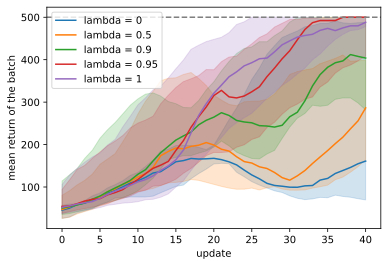

In [18]:
for lam, r in sweep.items():
    best = np.array([np.convolve(c, np.ones(20) / 20, 'valid').max()
                     for c in r])
    print(f'lambda = {lam:4}: best 20-update window, '
          f'median {np.median(best):5.1f}, seeds {np.round(np.sort(best))}')
d2l.plot_curves({f'lambda = {lam:g}': r for lam, r in sweep.items()},
                xlabel='update', ylabel='mean return of the batch',
                smooth=10, reference=500)

The $\lambda=0$ and $\lambda=0.5$ runs remain far below the maximum return when the 50-update budget ends, whereas the seed ranges for $\lambda\geq0.9$ overlap. Early in training, the critic is inaccurate, so estimators that depend less on it improve faster. The longer comparison above showed the complementary result: after the critic improves, the $\lambda=0$ runs have the longest consecutive intervals at the maximum return.

Training curves combine estimator quality with optimization and changing data. To examine the estimator directly, we freeze a partially trained agent and draw many batches at fixed parameters. For each $\lambda$, we compare the resulting policy-gradient estimates with a reference.

The reference is the mean of the $\lambda=1$ estimator over all draws. It approximates the unbiased Monte Carlo gradient without requiring a solvable model, although it remains subject to finite-sample error.

In [19]:
rng, env = np.random.default_rng(1), gym.make('CartPole-v1')
frozen = cartpole_agent(1)
env.reset(seed=1)
for _ in range(40):   # a mid-training freeze: the critic is still wrong
    b = d2l.rollout(env, frozen.act, batch_episodes, rng)
    for _ in range(critic_steps):
        fit_value(frozen, b.obs, b.td_target(frozen.value_np, gamma))
    policy_step_clip(frozen, b, d2l.normalize(
        b.td_target(frozen.value_np, gamma) - frozen.value_np(b.obs)))

In [20]:
@nnx.jit
def _grad_tree(policy, obs, act, adv, n_real):
    return nnx.grad(lambda p: -(adv * jax.nn.log_softmax(p(obs), -1)[
        jnp.arange(obs.shape[0]), act]).sum() / n_real)(policy)

def grad_vec(ac, b, w):   # padded + jitted: 1000 calls below
    size = 1 << max(6, (len(w) - 1).bit_length())
    g = _grad_tree(ac.policy, _pad(b.obs, size), _pad(b.act, size),
                   _pad(w, size), jnp.float32(len(w)))
    return np.concatenate([np.asarray(x).ravel()
                           for x in jax.tree.leaves(g)])

draws = {lam: [] for lam in lams}
for _ in range(200):
    b = d2l.rollout(env, frozen.act, 4, rng)
    for lam in lams:
        draws[lam].append(grad_vec(frozen, b,
                                   b.gae(frozen.value_np, gamma, lam)))
u_ref = np.stack(draws[1.0]).mean(axis=0)   # the many-rollout reference
for lam in lams:
    u = np.stack(draws[lam])
    bias = np.linalg.norm(u.mean(0) - u_ref) / np.linalg.norm(u_ref)
    var = ((u - u.mean(0)) ** 2).sum(1).mean() / (u_ref ** 2).sum()
    print(f'lambda = {lam:4}: relative bias {bias:4.2f}, relative '
          f'variance {var:6.1f}, one-draw error {bias ** 2 + var:6.1f}')

lambda =  0.0: relative bias 1.34, relative variance    0.3, one-draw error    2.1
lambda =  0.5: relative bias 1.22, relative variance    0.4, one-draw error    1.9
lambda =  0.9: relative bias 0.57, relative variance    1.4, one-draw error    1.7
lambda = 0.95: relative bias 0.26, relative variance    2.4, one-draw error    2.5
lambda =  1.0: relative bias 0.00, relative variance    5.9, one-draw error    5.9


Moving from $\lambda=1$ toward smaller values first reduces variance rapidly; most of the reduction has occurred by $\lambda=0.9$. Bias increases more gradually toward $\lambda=0$. The estimated one-draw error, bias squared plus variance, is therefore large at both endpoints and smallest between $\lambda=0.9$ and $0.95$ in these experiments. Common PPO implementations use values in this range (that section).

The location is not universal. It depends on the accuracy of the frozen critic and on the task. Moreover, the $\lambda=1$ row has zero estimated bias by construction because its sample mean defines the reference.

The reference itself is estimated from 200 draws of the highest-variance estimator. The bias column is therefore reliable only for differences large relative to this finite-sample error; the reported large-$\lambda$ differences satisfy that condition.

Finally, we evaluate the trained policies from seed 0 greedily, removing action-sampling variability from the comparison.

In [21]:
env = gym.make('CartPole-v1')
for name in runs:
    env.reset(seed=2)
    score = d2l.evaluate(env, agents[name][0].act_greedy, num_episodes=100)
    print(f'{name:>20}: greedy mean return over 100 episodes: {score:.0f}')

REINFORCE + baseline: greedy mean return over 100 episodes: 499


        actor-critic: greedy mean return over 100 episodes: 500


Both agents finish at 499 or 500, so this experiment does not rank their
final policies. It instead compares estimator variance, gradient norms,
and the persistence of ceiling-level batches during training.

## Summary

Actor--critic methods use a learned value function to construct bootstrapped policy-gradient weights. With an exact critic, the expected temporal-difference error equals the advantage; an approximate critic introduces bias while usually reducing variance. The critic update is a semi-gradient policy-evaluation step, and the actor and critic form an approximate generalized policy-iteration scheme. Multi-step returns interpolate between one-step bootstrapping and Monte Carlo returns. The $\lambda$-return mixes these targets geometrically, and GAE computes the equivalent discounted sum of temporal-difference errors with a backward scan.

**Experimental scope.** The training comparisons use three seeds per framework, the $\lambda$ sweep uses five seeds, and the frozen-policy estimator study uses 200 batches. Both one-step and Monte Carlo methods solve CartPole in these runs. Intermediate high values of $\lambda$ give the smallest estimator error on the frozen-policy probe, but the precise optimum varies by framework and policy. The experiments support the bias--variance interpretation rather than a universal choice of $\lambda$.

## Exercises

1. [conceptual] *Why the baseline argument does not extend.* The identity of
   that section allowed any $b(s_t)$ to be subtracted from the
   weight without bias. Explain why it does not cover the bootstrapped weight
   $\delta_t$ of the equation, by pointing at exactly which quantity
   in the argument stops being independent of the action $a_t$. Under what
   condition on $\hat{V}$ does the bias vanish?
1. [short-code] *Where the U comes from.* Take the estimator table's relative
   bias and variance per $\lambda$ and combine them into a predicted
   single-draw error, then predict which $\lambda$ the training sweep should
   favor *before* looking at its returns. Where prediction and sweep disagree,
   what does the disagreement say about what a training run adds that a
   frozen-policy estimate cannot see? (The critic improves during training,
   the policy moves, and the weight scale interacts with the step size.)
1. [short-code] *The two timescales.* Sweep `critic_steps` over
   $\{1, 5, 20\}$, two seeds each; about twenty minutes on a laptop CPU. Where
   does the algorithm fail, and does it fail by learning nothing or by
   learning something wrong? Connect the failure to the sentence in the
   two-timescale paragraph about the critic chasing a moving target twice
   over.
1. [short-code] *The clip, removed.* Log the norm of the policy gradient in
   both methods, before the clip is applied. Although both normalize their
   weights to unit variance, the actor-critic norms come out roughly an order
   of magnitude larger. Explain the gap with the baseline argument of
   that section, then predict, and check, which of the two runs
   changes at all when `grad_clip` is removed.
1. [extended] *Fully online.* the equation can be applied at every
   single transition, with no batch at all. Implement this variant on CartPole
   and compare it with the batched version at a matched number of environment
   steps. What goes wrong, and which ingredient of that section's recipe
   addresses it?
1. [conceptual] *Where the actor-critic sits.* Place REINFORCE, REINFORCE with
   a learned baseline, actor-critic, and Q-learning on two axes: how much bias
   the update carries, and how long the algorithm must wait before it can
   learn from a transition. Which corner is empty, and why?

[Discussions](https://d2l.discourse.group/)